In [5]:
import math, random, os
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.9.0+cpu | Device: cpu


In [6]:
# 7) GAN — Sinh dữ liệu two-moons (2D)

Epoch 50: lossD=1.166 lossG=0.747
Epoch 100: lossD=1.476 lossG=0.759
Epoch 150: lossD=1.247 lossG=0.709
Epoch 200: lossD=1.312 lossG=0.777
Epoch 250: lossD=1.403 lossG=0.700
Epoch 300: lossD=1.389 lossG=0.793
Epoch 350: lossD=1.254 lossG=0.742
Epoch 400: lossD=1.503 lossG=0.704


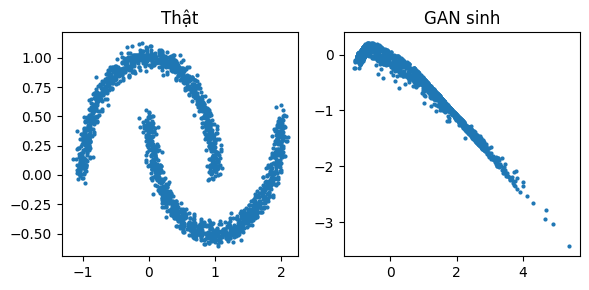

In [7]:

X,_=make_moons(2000, noise=0.05, random_state=0)
X=X.astype(np.float32)
class G(nn.Module):
    def __init__(self): super().__init__(); self.net=nn.Sequential(
        nn.Linear(2,32), nn.ReLU(), nn.Linear(32,32), nn.ReLU(), nn.Linear(32,2))
    def forward(self,z): return self.net(z)
class D(nn.Module):
    def __init__(self): super().__init__(); self.net=nn.Sequential(
        nn.Linear(2,32), nn.ReLU(), nn.Linear(32,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())
    def forward(self,x): return self.net(x)

Gm, Dm = G().to(device), D().to(device)
optG=optim.Adam(Gm.parameters(), lr=1e-3); optD=optim.Adam(Dm.parameters(), lr=1e-3)
bce=nn.BCELoss(); data=torch.tensor(X, device=device); B=128

for ep in range(1, 401):
    idx=torch.randperm(data.size(0), device=device)
    for i in range(0, len(idx), B):
        real=data[idx[i:i+B]]
        z=torch.randn(real.size(0),2, device=device)
        # D
        optD.zero_grad()
        lossD = bce(Dm(real), torch.ones(real.size(0),1, device=device)) +                 bce(Dm(Gm(z).detach()), torch.zeros(real.size(0),1, device=device))
        lossD.backward(); optD.step()
        # G
        optG.zero_grad()
        lossG = bce(Dm(Gm(z)), torch.ones(real.size(0),1, device=device))
        lossG.backward(); optG.step()
    if ep%50==0: print(f"Epoch {ep}: lossD={lossD.item():.3f} lossG={lossG.item():.3f}")

with torch.no_grad():
    gen=Gm(torch.randn(2000,2, device=device)).cpu().numpy()

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.scatter(X[:,0],X[:,1],s=4); plt.title("Thật")
plt.subplot(1,2,2); plt.scatter(gen[:,0],gen[:,1],s=4); plt.title("GAN sinh")
plt.tight_layout(); plt.show()
